In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import statistics

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


# Left STN

In [2]:
class LeadDBS_atlases_random_point_generator:
    def __init__(self, atlas, stimulating_electrode_position, encapsulation_radius):
        self.atlas = atlas
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius
        
        
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = (x_coordinates**2 + y_coordinates**2 > self.encapsulation_radius**2) & (x_coordinates < 0)
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [3]:
class LeadDBS_HDP_atlas_collateral_random_point_generator:
    def __init__(self, atlas, x_lower_limit, x_upper_limit, y_lower_limit, y_upper_limit, z_lower_limit, z_upper_limit):
        self.atlas = atlas     
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine
        self.x_lower_limit = x_lower_limit
        self.x_upper_limit = x_upper_limit
        self.y_lower_limit = y_lower_limit
        self.y_upper_limit = y_upper_limit
        self.z_lower_limit = z_lower_limit
        self.z_upper_limit = z_upper_limit

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] 
        y_coordinates = world_points[:, 1] 
        z_coordinates = world_points[:, 2]


        mask = ((x_coordinates > self.x_lower_limit) & (x_coordinates < self.x_upper_limit) & (y_coordinates > self.y_lower_limit) & (y_coordinates < self.y_upper_limit) & (z_coordinates > self.z_lower_limit) & (z_coordinates < self.z_upper_limit))
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [4]:
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_radius):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points


In [5]:
def collateral_positions_along_HDP(HDP_STN_coordinates, HDP_axon_coordinates, n, nseg=11):
    distances = (HDP_STN_coordinates - HDP_axon_coordinates)/nseg
    collateral_coordinates = np.zeros((n, nseg, 3))
    for cell_number in range(n):
        collateral_coordinates[cell_number, 0] = HDP_STN_coordinates[cell_number]
        for seg_number in range(1, nseg):
            collateral_coordinates[cell_number, seg_number] = HDP_STN_coordinates[cell_number] - seg_number*distances[cell_number]         
     
    return collateral_coordinates 

In [10]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")
electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) left"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_julich = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
positions_julich = random_point_generator_julich.generate_positions(1000)

random_point_generator_HDP = LeadDBS_atlases_random_point_generator(atlas_HDP, electrode_position_mm, encapsulation_mm)
positions_HDP = random_point_generator_HDP.generate_positions(1000)

In [11]:
random_point_generator_HDP_collaterals = LeadDBS_HDP_atlas_collateral_random_point_generator(atlas_HDP, -27.5, -22.5, -20, 0, 10, 30)
positions_HDP_collaterals_upper = random_point_generator_HDP_collaterals.generate_positions(100)

random_point_generator_HDP_collaterals = LeadDBS_HDP_atlas_collateral_random_point_generator(atlas_HDP, -17.5, -10, -20, -10, -20, 0)
positions_HDP_collaterals_lower = random_point_generator_HDP_collaterals.generate_positions(100)

collateral_positions = collateral_positions_along_HDP(positions_ewert_collaterals, positions_HDP_collaterals, 100)

NameError: name 'positions_ewert_collaterals' is not defined

NameError: name 'collateral_positions' is not defined

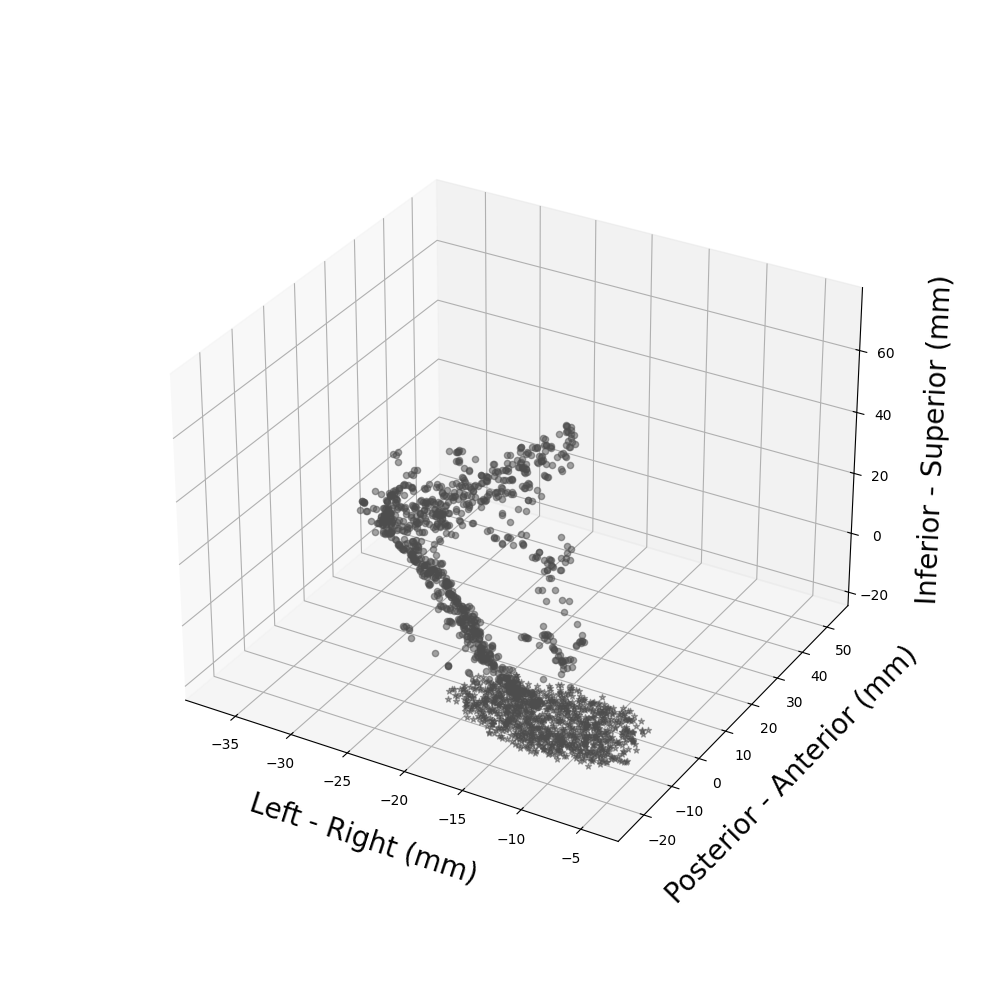

In [9]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_julich[:,0]
y_points_ewert = positions_julich[:,1]
z_points_ewert = positions_julich[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='#4D4D4D', label = "STN neurons (LFP source)", depthshade=False, alpha = 0.5, linewidth = 1, marker='*')

##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='#4D4D4D', label = "Hyperdirect Pathway", depthshade=False, alpha = 0.5, linewidth= 1, axlim_clip=True)

for i in range(0, 100):
    x_points_collateral = collateral_positions[:,:,0][i]
    y_points_collateral = collateral_positions[:,:,1][i]
    z_points_collateral = collateral_positions[:,:,2][i]
    if i == 0:
        ax.plot(x_points_collateral, y_points_collateral, z_points_collateral, c='#332288', label = "Simulated Collateral")
    else:
        ax.plot(x_points_collateral, y_points_collateral, z_points_collateral, c='#332288')

###############################################################
#electrode
ax.scatter(np.array([-12]), np.array([-12]), np.array([-8.5]), c='#882255', label = "Electrode", linewidth=4)
ax.scatter(np.array([-12,-12]), np.array([-12,-12]), np.array([-8,-9]), color='#882255', depthshade=False, linewidth=4)
#############efield
x0, y0, z0 = -12, -12, -8.5 

x = np.linspace(-2.5, -30, 15)
y = np.linspace(-22.5, -2, 15)
z = np.linspace(-20, 30, 15)

X, Y, Z = np.meshgrid(x, y, z)

# -------------------------
# Shift coordinates
# -------------------------
Rx = X - x0
Ry = Y - y0
Rz = Z - z0

r = np.sqrt(Rx**2 + Ry**2 + Rz**2)

# Avoid singularity
mask = r > 0.5

# Electric field (no constants for visualization)
Ex = np.zeros_like(Rx)
Ey = np.zeros_like(Ry)
Ez = np.zeros_like(Rz)

Ex[mask] = Rx[mask] / r[mask]
Ey[mask] = Ry[mask] / r[mask]
Ez[mask] = Rz[mask] / r[mask]

# -------------------------
# Normalize for clean arrows
# -------------------------
norm = np.sqrt(Ex**2 + Ey**2 + Ez**2)
norm[norm == 0] = 1

Exn = Ex / norm
Eyn = Ey / norm
Ezn = Ez / norm

# -------------------------
# Plot
# -------------------------


step = 3
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    Exn[::step, ::step, ::step],
    Eyn[::step, ::step, ::step],
    Ezn[::step, ::step, ::step],
    length=0.8,
    color='#882255', 
    alpha = 0.5
)

###############################################################

legend = ax.legend(loc='upper left', shadow=True, markerscale=2., scatterpoints=1, fontsize=17.5)

ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)

ax.axes.set_xlim3d(left=-30, right=0)
ax.axes.set_ylim3d(bottom=-30, top=0)
ax.axes.set_zlim3d(bottom=-20, top=50)

plt.show()
#plt.savefig("stimulated_collaterals_HDP_with_point_source.svg", format="svg")

# Right STN

In [2]:
class LeadDBS_atlases_random_point_generator:
    def __init__(self, atlas, stimulating_electrode_position, encapsulation_radius):
        self.atlas = atlas
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius
        
        
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0.2)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)
        
        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [3]:
class LeadDBS_HDP_atlas_collateral_random_point_generator:
    def __init__(self, atlas, x_lower_limit, x_upper_limit, y_lower_limit, y_upper_limit, z_lower_limit, z_upper_limit, stimulating_electrode_position, encapsulation_radius):
        self.atlas = atlas     
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine
        self.x_lower_limit = x_lower_limit
        self.x_upper_limit = x_upper_limit
        self.y_lower_limit = y_lower_limit
        self.y_upper_limit = y_upper_limit
        self.z_lower_limit = z_lower_limit
        self.z_upper_limit = z_upper_limit

        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius
        

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0.2)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] 
        y_coordinates = world_points[:, 1] 
        z_coordinates = world_points[:, 2]


        mask = ((x_coordinates > self.x_lower_limit) & (x_coordinates < self.x_upper_limit) & (y_coordinates > self.y_lower_limit) & (y_coordinates < self.y_upper_limit) & (z_coordinates > self.z_lower_limit) & (z_coordinates < self.z_upper_limit))
        
        
        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]
        
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = (x_coordinates**2 + y_coordinates**2 > self.encapsulation_radius**2) & (x_coordinates > 0)
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]        
        

        return world_points

In [4]:
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_radius):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0.2)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points


In [13]:
def collateral_positions_along_HDP(HDP_STN_coordinates, HDP_axon_coordinates, n, stimulating_electrode_position, encapsulation_radius, nseg=1000):
    directions = (-HDP_axon_coordinates+HDP_STN_coordinates)
    magnitude = np.linalg.norm(directions, axis=1)
    distances = (directions/magnitude[:, None])*(25000/nseg) 
    collateral_coordinates = np.zeros((n, nseg, 3))
    for cell_number in range(n):
        collateral_coordinates[cell_number, 0] = HDP_STN_coordinates[cell_number]
        for seg_number in range(1, nseg):
            test_position = HDP_STN_coordinates[cell_number] - seg_number*distances[cell_number]          
            path_to_center_vec = test_position[0:2] - stimulating_electrode_position[0:2]
            norm = np.linalg.norm(path_to_center_vec)
            if norm < encapsulation_radius:
                path_to_center_vec /= norm
                test_position[0:2] = stimulating_electrode_position[0:2]+encapsulation_radius*path_to_center_vec*1.1                
            collateral_coordinates[cell_number, seg_number] = test_position 
    return collateral_coordinates 

In [14]:
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")


parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) right"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([12000, -13500, -8300])/1000
encapsulation_mm = 1135/1000

random_point_generator_julich = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
positions_julich = random_point_generator_julich.generate_positions(1000)*1000

random_point_generator_HDP = LeadDBS_atlases_random_point_generator(atlas_HDP, electrode_position_mm, encapsulation_mm)
positions_HDP = random_point_generator_HDP.generate_positions(1000)*1000

In [15]:

random_point_generator_HDP_collaterals = LeadDBS_HDP_atlas_collateral_random_point_generator(atlas_HDP, 22.5, 27.5, -20, 0, 10, 30,electrode_position_mm, encapsulation_mm)
positions_HDP_collaterals_upper = random_point_generator_HDP_collaterals.generate_positions(100)*1000
'''
random_point_generator_HDP_collaterals = LeadDBS_HDP_atlas_collateral_random_point_generator(atlas_HDP, 10, 25, -20, -5, -20, 0,electrode_position_mm, encapsulation_mm)
positions_HDP_collaterals_lower = random_point_generator_HDP_collaterals.generate_positions(100)
'''



atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_right.nii")
random_point_generator_ewert = LeadDBS_atlases_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_HDP_collaterals_lower = random_point_generator_ewert.generate_positions(100)*1000

electrode_position= np.array([12000, -13500, -8300])
encapsulation = 1135


collateral_positions = collateral_positions_along_HDP(positions_HDP_collaterals_lower, positions_HDP_collaterals_upper, 100, electrode_position, encapsulation)




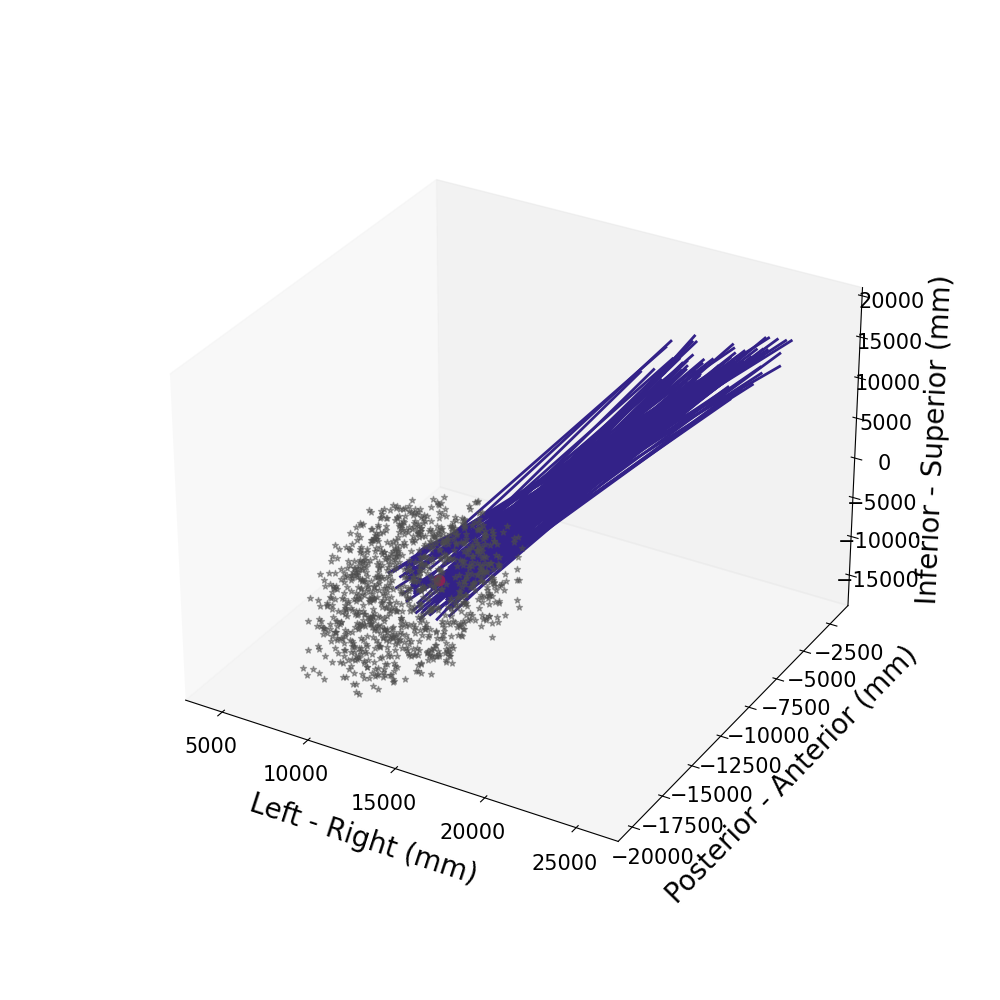

In [16]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### julich ##############

x_points_ewert = positions_julich[:,0]
y_points_ewert = positions_julich[:,1]
z_points_ewert = positions_julich[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='#4D4D4D', label = "STN neurons (LFP source)", depthshade=False, alpha = 0.5, linewidth = 1, marker='*')
'''
##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='#4D4D4D', label = "Hyperdirect Pathway", depthshade=False, alpha = 0.5, linewidth= 1, axlim_clip=True)
'''
for i in range(0, 100):
    x_points_collateral = collateral_positions[:,:,0][i]
    y_points_collateral = collateral_positions[:,:,1][i]
    z_points_collateral = collateral_positions[:,:,2][i]
    if i == 0:
        ax.plot(x_points_collateral, y_points_collateral, z_points_collateral, c='#332288', label = "Simulated Collateral", linewidth=2)
    else:
        ax.plot(x_points_collateral, y_points_collateral, z_points_collateral, c='#332288', linewidth=2)

###############################################################
#electrode
ax.scatter(np.array([12000]), np.array([-13500]), np.array([-8300]), c='#882255', label = "Electrode", linewidth=4)
#ax.scatter(np.array([12,12]), np.array([-12,-12]), np.array([-8,-9]), color='#882255', depthshade=False, linewidth=4)
'''
#############efield
x0, y0, z0 = 12, -12, -8.5 

x = np.linspace(2.5, 30, 15)
y = np.linspace(-22.5, -2, 15)
z = np.linspace(-20, 30, 15)

X, Y, Z = np.meshgrid(x, y, z)

# -------------------------
# Shift coordinates
# -------------------------
Rx = X - x0
Ry = Y - y0
Rz = Z - z0

r = np.sqrt(Rx**2 + Ry**2 + Rz**2)

# Avoid singularity
mask = r > 0.5

# Electric field (no constants for visualization)
Ex = np.zeros_like(Rx)
Ey = np.zeros_like(Ry)
Ez = np.zeros_like(Rz)

Ex[mask] = Rx[mask] / r[mask]
Ey[mask] = Ry[mask] / r[mask]
Ez[mask] = Rz[mask] / r[mask]

# -------------------------
# Normalize for clean arrows
# -------------------------
norm = np.sqrt(Ex**2 + Ey**2 + Ez**2)
norm[norm == 0] = 1

Exn = Ex / norm
Eyn = Ey / norm
Ezn = Ez / norm

# -------------------------
# Plot
# -------------------------


step = 3
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    Exn[::step, ::step, ::step],
    Eyn[::step, ::step, ::step],
    Ezn[::step, ::step, ::step],
    length=0.8,
    color='#882255', 
    alpha = 0.5
)
'''
###############################################################

#legend = ax.legend(loc='upper left', shadow=True, markerscale=2., scatterpoints=1, fontsize=17.5)

ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)
'''
ax.axes.set_xlim3d(left=0, right=30)
ax.axes.set_ylim3d(bottom=-30, top=0)
ax.axes.set_zlim3d(bottom=-20, top=50)
'''
plt.show()
#plt.savefig("stimulated_collaterals_HDP_with_point_source.svg", format="svg")